In [1]:
import os,glob
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,r2_score

# 设置matplotlib库字体的非衬线字体为黑体
plt.rcParams["font.sans-serif"]=["SimHei"]
# 设置matplotlib库字体族为非衬线字体
plt.rcParams["font.family"] = ["SimHei"]

In [2]:
def set_dt_idx(df,col='日期时间'):
    '''
    设置日期时间索引
    '''
    df[col] = pd.to_datetime(df[col])
    df.set_index(col,inplace=True)
    
    return df   

def set_cols_num(df,cols):
    '''
    设置列为数值型
    '''
    for c in cols:
        df[c] = pd.to_numeric(df[c],errors='coerce')
    
    return df

def cumm2dayvar(df):
    '''
    累积值转日变化量
    '''
    var = df.shift(-1) - df
    day_var = var.resample('D').sum()
    
    return day_var

# 出效果图

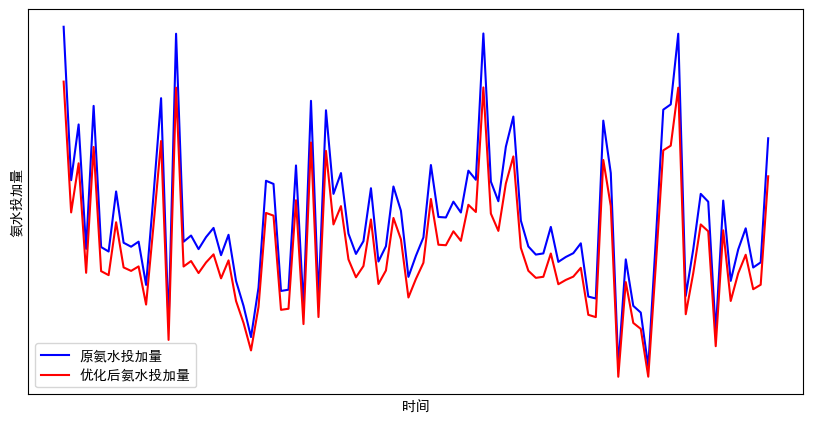

In [5]:
pth = r'F:\项目数据\水处理\效果图'
os.chdir(pth)

file = '氨水投加.xlsx'
df = pd.read_excel(file)
x = list(range(len(df)))
fig,axs = plt.subplots(figsize=(10,5))
axs.plot(df['原氨水投加量'],label='原氨水投加量',c='blue')
axs.plot(df['优化后氨水投加量'],label='优化后氨水投加量',c='red')
# axs.plot(x['进水COD'],label='进水COD')
# axs.plot(x['进水TN'],label='进水TN')
axs.legend()
axs.set_ylabel('氨水投加量')
axs.set_xlabel('时间')
axs.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
axs.tick_params(axis='y', which='both', left=False, labelleft=False)
fig.savefig('氨水投加量.jpg')

# 数据准备

In [3]:
pth = r'F:\项目数据\污水处理系统碳源投放优化'
os.chdir(pth)

In [4]:
df1 = pd.read_excel('进出水水质报表.xlsx').iloc[0:-1,:]
df2 = pd.read_excel('加药累计流量.xlsx').iloc[0:-1,:]
df3 = pd.read_excel('2025.01-07.xlsx').iloc[0:-1,:]
df4 = pd.read_excel('温度-5D.xls')

In [5]:
df1 = set_dt_idx(df1)
df2 = set_dt_idx(df2)
df3 = set_dt_idx(df3)
df4 = set_dt_idx(df4,'采样时间')
df4 = set_cols_num(df4,['水温'])
df4 = df4.loc[:,['水温']]

In [6]:
df1.to_excel('进出水水质报表-预处理1.xlsx')
df2.to_excel('加药累计流量-预处理1.xlsx')
df3.to_excel('2025.01-07-预处理1.xlsx')
df4.to_excel('温度-5D-预处理1.xlsx')

# 检查数据是否可用

1、进出口数据能匹配上

2、出口数据相对达标值的差异性足够

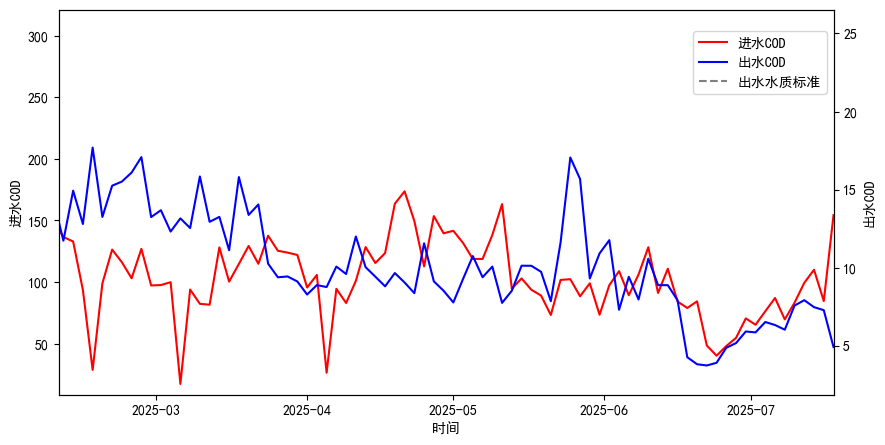

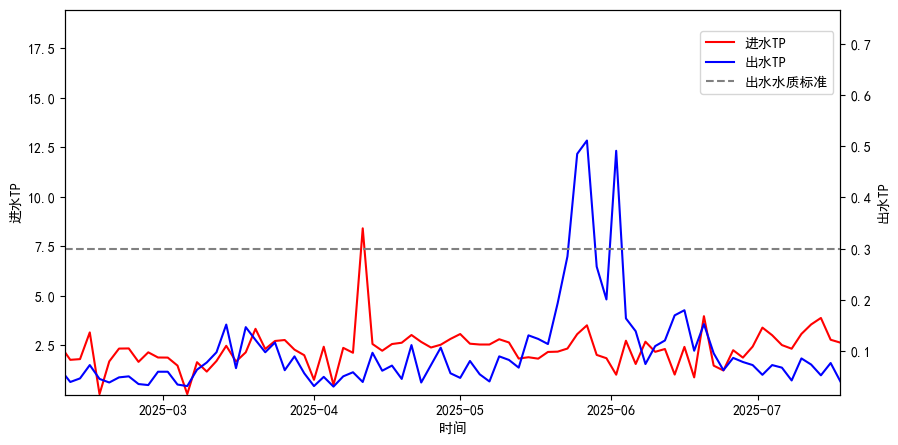

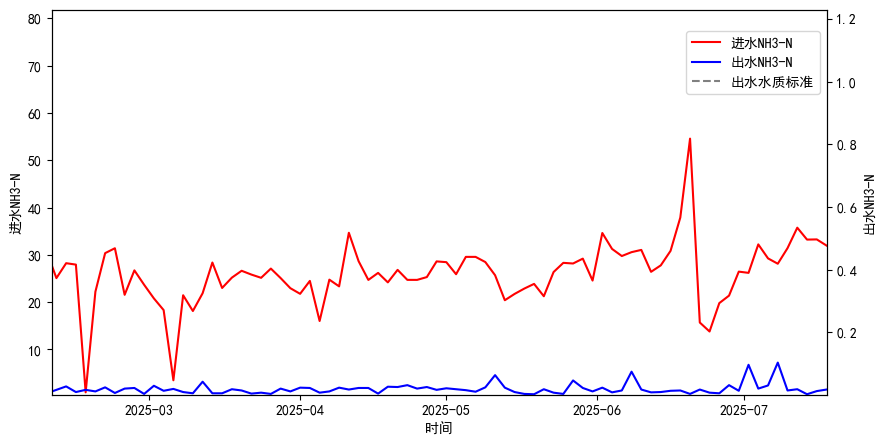

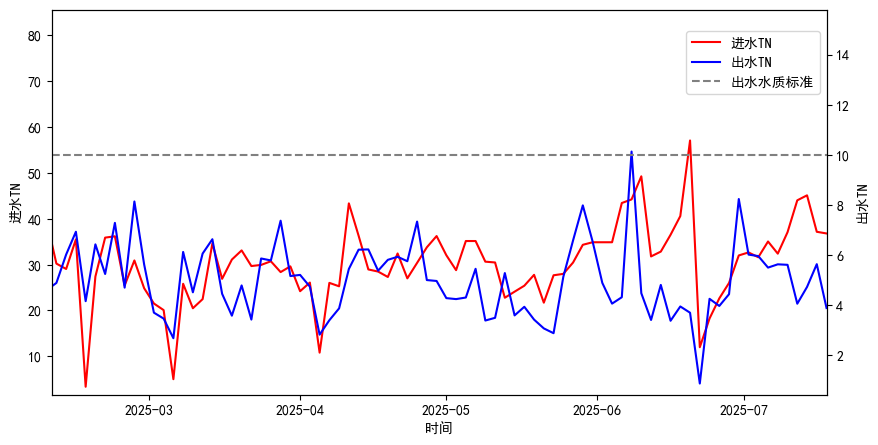

In [7]:
st_v = [30,0.3,1.5,10]
for i,zb in enumerate(['COD','TP','NH3-N','TN']):
    fig,ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(df1[f"进水{zb}"],c='r',label=f"进水{zb}")
    ax1.set_ylim(df1[f"进水{zb}"].min()*0.5,df1[f"进水{zb}"].max()*1.5)
    ax1.set_ylabel(f"进水{zb}")
    ax1.set_xlabel('时间')
    ax1.set_xlim(pd.to_datetime('2025-02-09'),pd.to_datetime('2025-07-18'))
    
    ax2 = ax1.twinx()
    ax2.plot(df1[f"出水{zb}"],c='b',label=f"出水{zb}")   
    ax2.set_ylim(df1[f"出水{zb}"].min()*0.5,df1[f"出水{zb}"].max()*1.5)
    ax2.axhline(st_v[i],ls='--',c='gray',label='出水水质标准')
    ax2.set_ylabel(f"出水{zb}")
    fig.legend(bbox_to_anchor=(0.9, 0.85))  
    
    fig.savefig(f"进出水变化趋势-{zb}.jpg")

In [8]:
# 进出水对齐时间
date1 = df1.loc['2025-03','进水TN'].idxmin()
date2 = df1.loc['2025-03','出水TN'].idxmin()
print(date1,date2)

2025-03-06 00:00:00 2025-03-06 00:00:00


# 简单相关性分析

<Axes: xlabel='日期时间'>

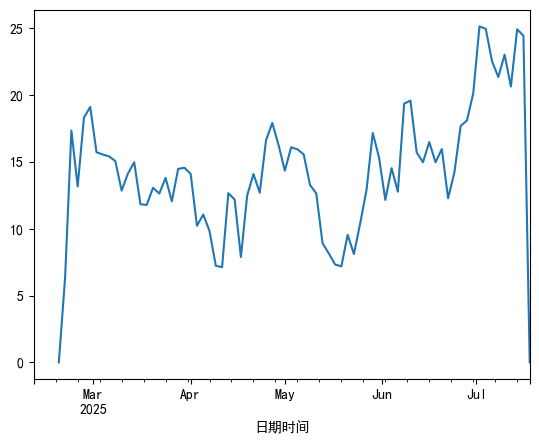

In [42]:
df21['加药累计流量\北池碳源'].plot()

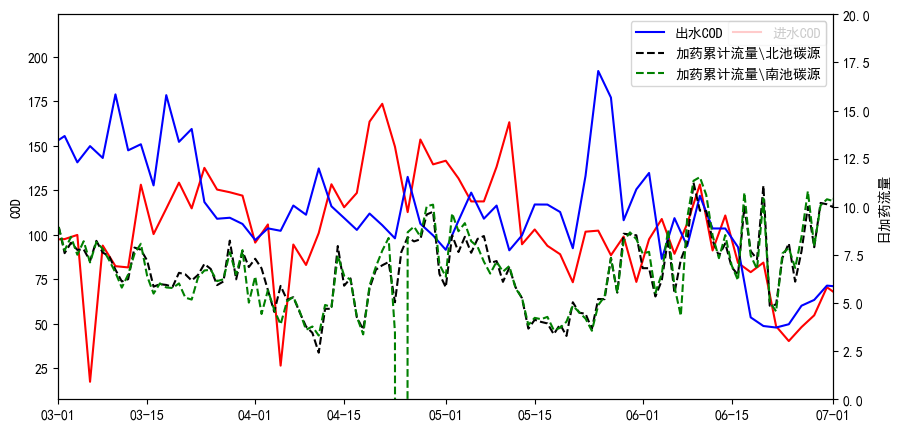

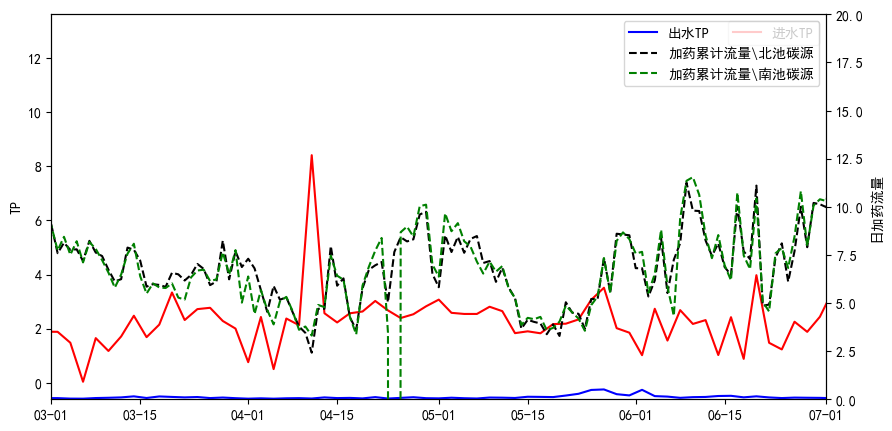

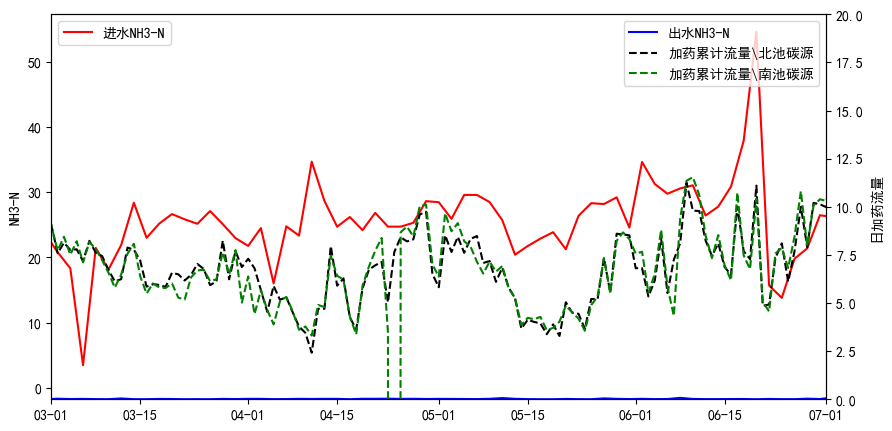

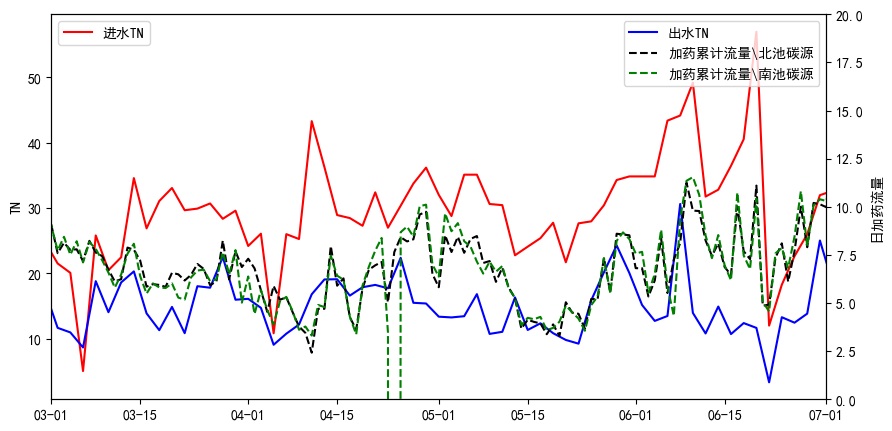

In [9]:
df2_day = cumm2dayvar(df2) # 碳源投放的日变化量

for zb in ['COD','TP','NH3-N','TN']:
    fig,ax = plt.subplots(figsize=(10,5))
    ax.plot(df1[f"进水{zb}"],c='r',label=f"进水{zb}")
#     ax.plot(df1[f"出水{zb}"],c='b',label=f"出水{zb}")
    ax.legend()
    ax.set_ylabel(zb)
    
    ax2 = ax.twinx()
    ax2.plot(df1[f"出水{zb}"],c='b',label=f"出水{zb}")
    ax2.plot(df2_day['加药累计流量\北池碳源'],label='加药累计流量\北池碳源',c='k',ls='--')
    ax2.plot(df2_day['加药累计流量\南池碳源'],label='加药累计流量\南池碳源',c='green',ls='--')
    ax2.set_ylim(0,20)    
    ax2.legend()
    ax2.set_ylabel('日加药流量')
    
    date_format = mdates.DateFormatter('%m-%d')
    ax.xaxis.set_major_formatter(date_format)
    ax.set_xlim(pd.to_datetime('2025-03'),pd.to_datetime('2025-07'))

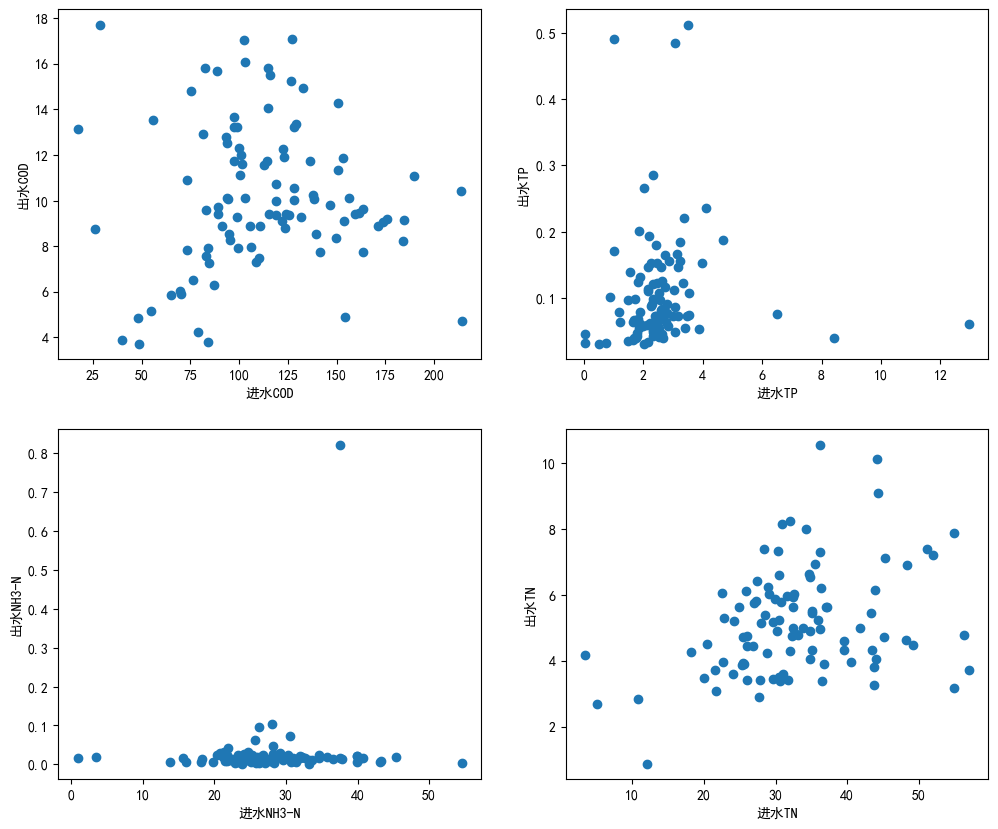

In [10]:
# 进出水水质
fig,axs = plt.subplots(2,2,figsize=(12,10))
for i,zb in enumerate(['COD','TP','NH3-N','TN']):    
    axs[i//2,i%2].scatter(df1[f"进水{zb}"],df1[f"出水{zb}"])   
    axs[i//2,i%2].set_xlabel(f"进水{zb}")
    axs[i//2,i%2].set_ylabel(f"出水{zb}")

Text(0, 0.5, '加药累计流量\\北池碳源')

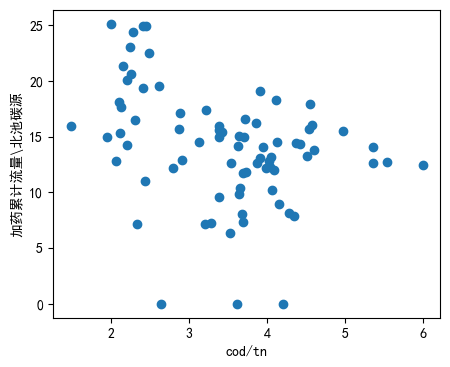

In [12]:
# 碳氮比与投药量
fig,axs = plt.subplots(figsize=(5,4))
df11 = df1.loc['2025-02-10':,:]
df21 = df2_day.iloc[1:,:].resample('2D').sum()
df21 = df21.mask(df21<0)
df21 = df21.mask(df21>10000)
axs.scatter(df11["进水COD"]/df11["进水TN"],df21['加药累计流量\北池碳源'])   
axs.set_xlabel('cod/tn')
axs.set_ylabel('加药累计流量\北池碳源')

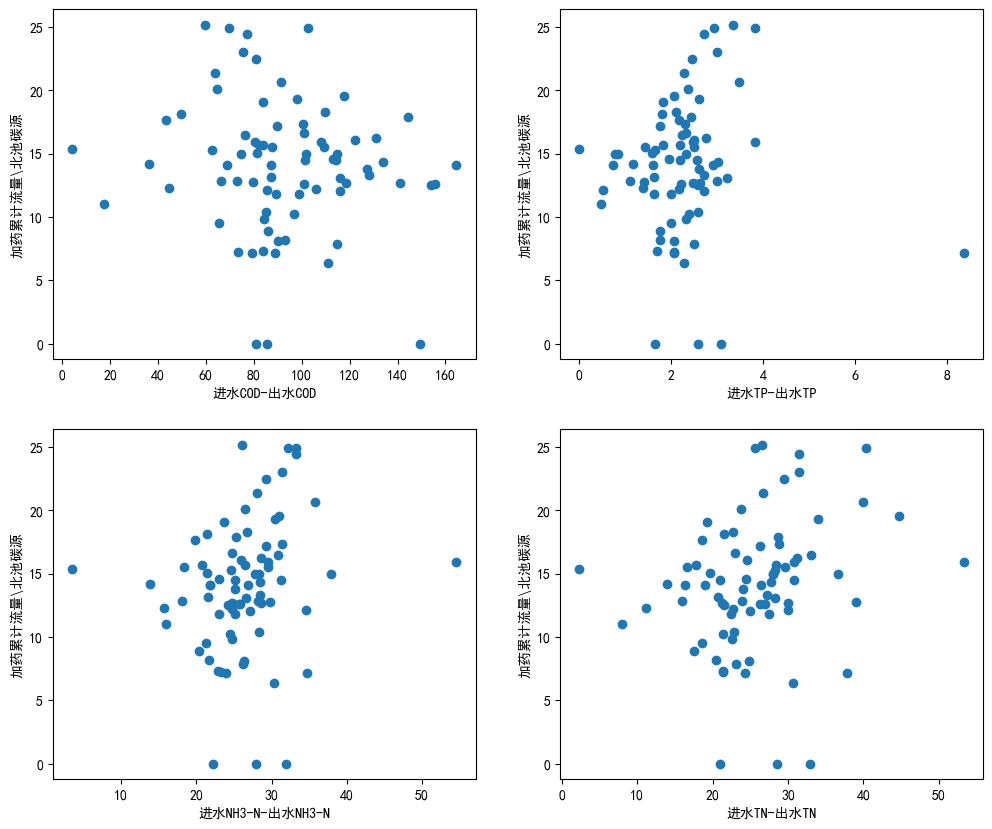

In [14]:
# 进出水水质变化与投药量
fig,axs = plt.subplots(2,2,figsize=(12,10))
for i,zb in enumerate(['COD','TP','NH3-N','TN']):    
    axs[i//2,i%2].scatter(df11[f"进水{zb}"]-df11[f"出水{zb}"],df21['加药累计流量\北池碳源'])   
    axs[i//2,i%2].set_xlabel(f"进水{zb}-出水{zb}")
    axs[i//2,i%2].set_ylabel("加药累计流量\北池碳源")

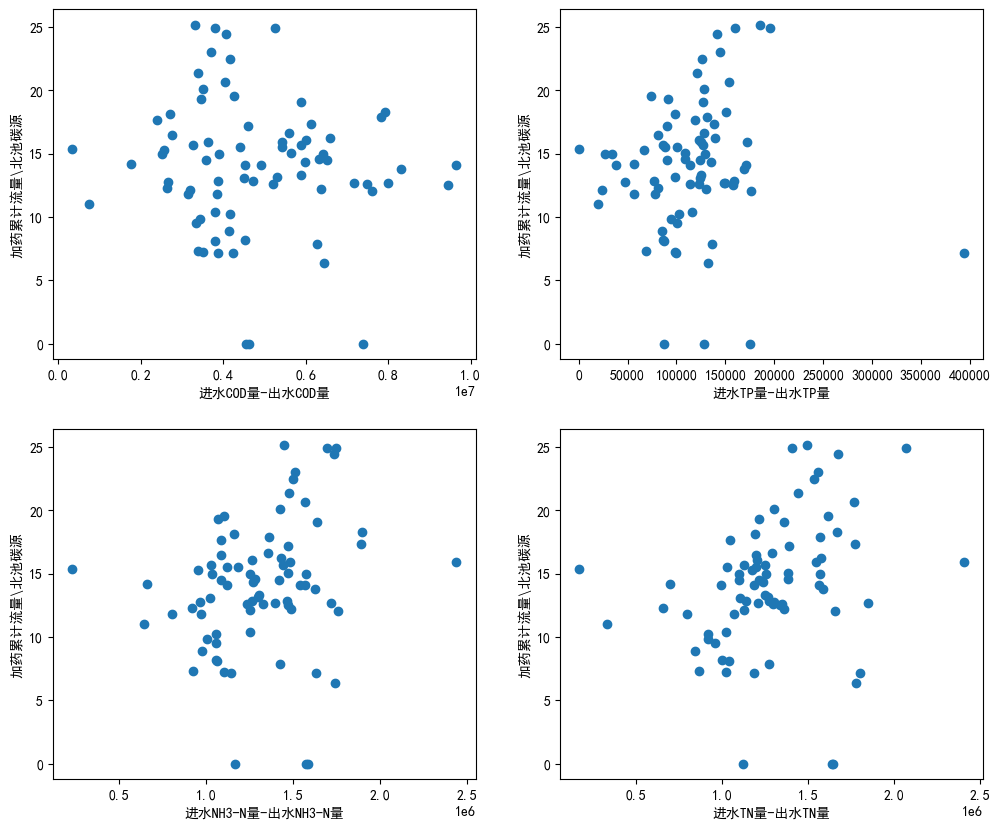

In [13]:
# 进出水污染物变化量与投药量
df3_day = cumm2dayvar(df3)
df31 = df3_day.loc['2025-02-10':].resample('2D').sum().loc[:'2025-07-18',:]

fig,axs = plt.subplots(2,2,figsize=(12,10))
for i,zb in enumerate(['COD','TP','NH3-N','TN']):    
    axs[i//2,i%2].scatter(df11[f"进水{zb}"]*df31['累积流量数据\进水累计流量']-df11[f"出水{zb}"]*df31["累积流量数据\出水累计流量"],
                          df21['加药累计流量\北池碳源'])   
    axs[i//2,i%2].set_xlabel(f"进水{zb}量-出水{zb}量")
    axs[i//2,i%2].set_ylabel("加药累计流量\北池碳源")

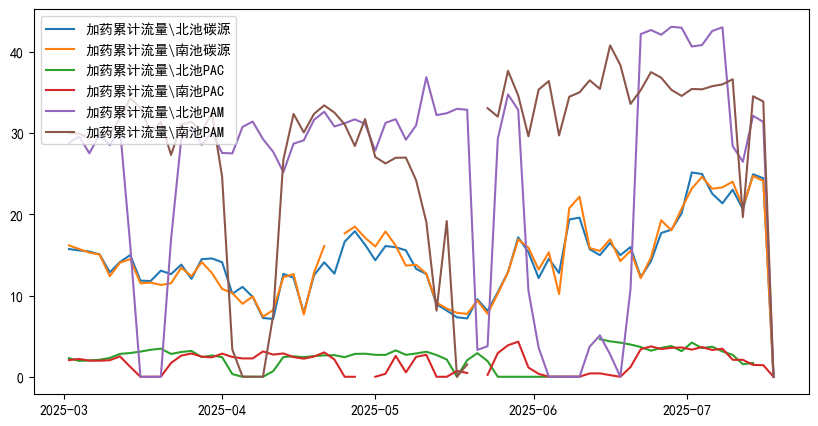

In [14]:
# 其他投药
fig,axs = plt.subplots(figsize=(10,5))
for c in df21.columns:
    axs.plot(df21.loc['2025-03':,c],label=c)
    axs.legend()

# XGBoost

## 准备数据

### 检查数据

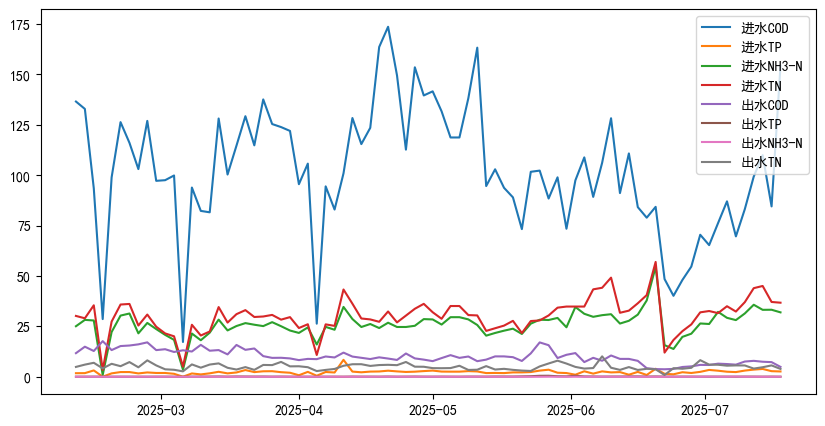

In [17]:
fig,axs = plt.subplots(figsize=(10,5))
for c in df11.columns:
    axs.plot(df11.loc[:,c],label=c)
    axs.legend()

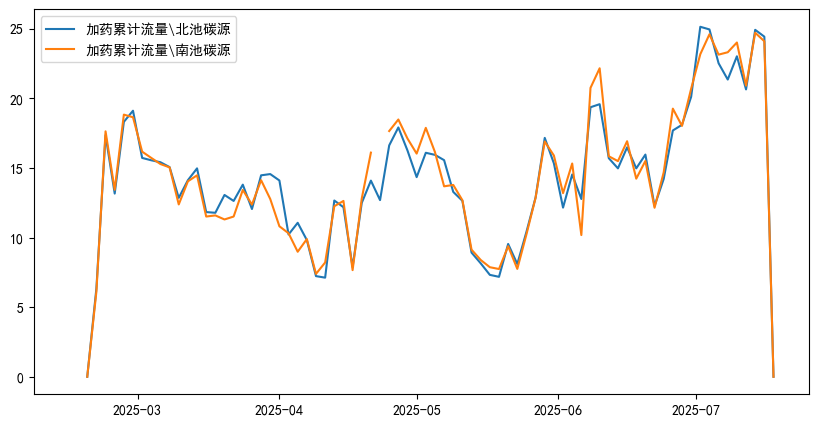

In [18]:
fig,axs = plt.subplots(figsize=(10,5))
for c in df21.columns[0:2]:
    axs.plot(df21.loc[:,c],label=c)
    axs.legend()

In [19]:
df21

,加药累计流量\北池碳源,加药累计流量\南池碳源,加药累计流量\北池PAC,加药累计流量\南池PAC,加药累计流量\北池PAM,加药累计流量\南池PAM
日期时间,,,,,,
2025-02-10,NaN,NaN,1626.25,1071.87,NaN,NaN
2025-02-12,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-14,0.00,0.00,1.85,0.00,0.00,20.48
2025-02-16,NaN,NaN,1.99,NaN,NaN,11.45
2025-02-18,0.00,0.00,1.89,0.00,0.00,0.00
...,...,...,...,...,...,...
2025-07-10,23.02,24.01,2.70,2.09,28.40,36.61
2025-07-12,20.64,20.91,1.55,2.09,26.45,19.65
2025-07-14,24.92,24.71,1.70,1.46,32.12,34.52


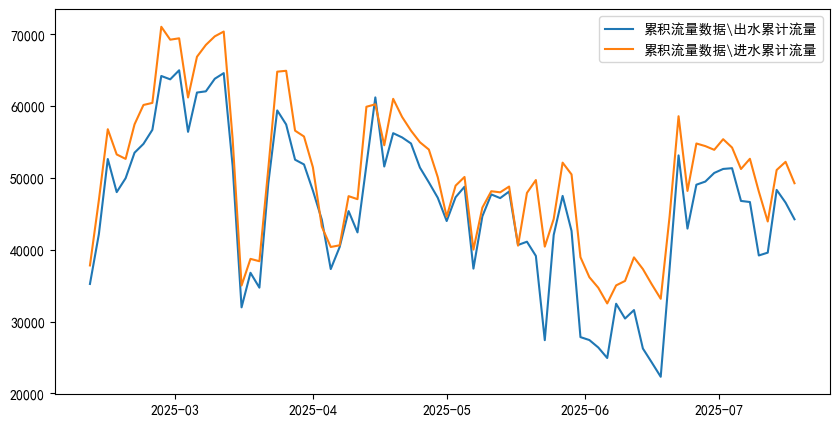

In [20]:
fig,axs = plt.subplots(figsize=(10,5))
for c in df31.columns:
    axs.plot(df31.loc[:,c],label=c)
    axs.legend()

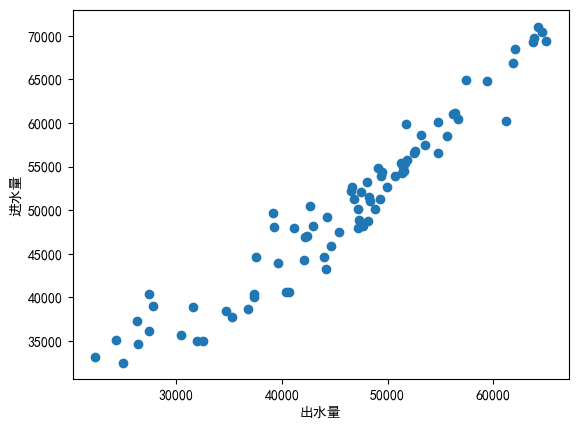

In [21]:
plt.scatter(df31.iloc[:,0],df31.iloc[:,1])
plt.xlabel('出水量')
plt.ylabel('进水量')
plt.savefig('进出水流量')

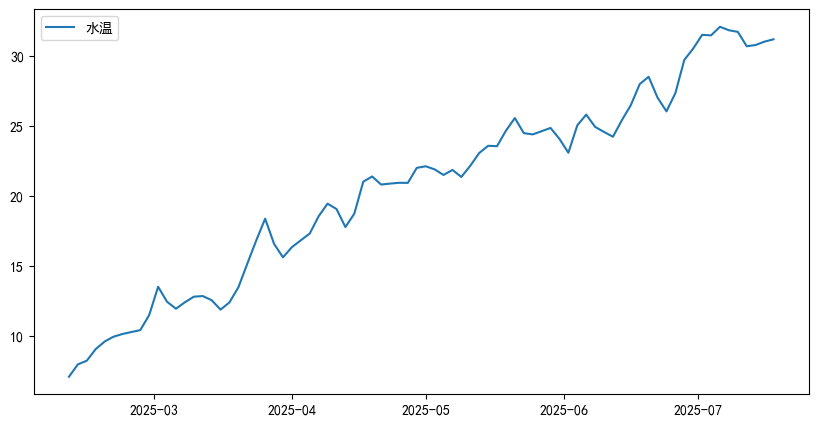

In [22]:
df41 = df4.loc['2025-02-10':'2025-07-18',:].resample('2D').mean()

fig,axs = plt.subplots(figsize=(10,5))
for c in df41.columns:
    axs.plot(df41.loc[:,c],label=c)
    axs.legend()

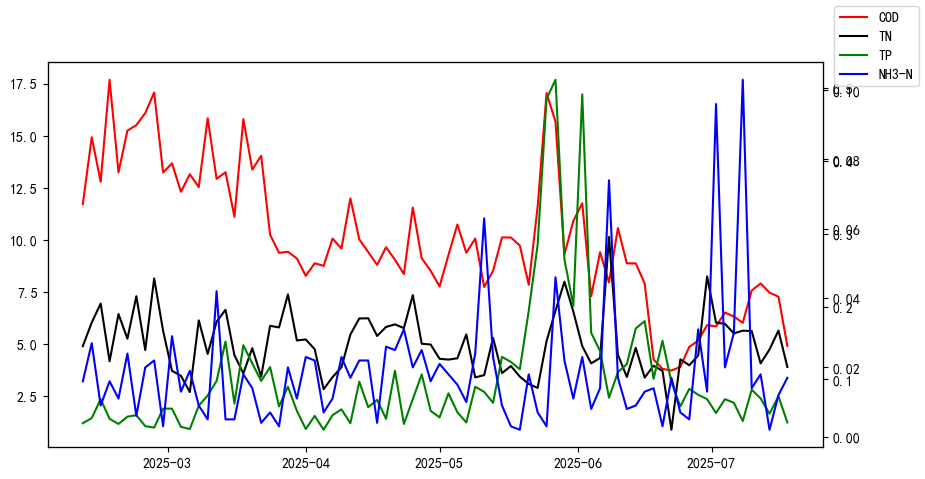

In [23]:
# 出水水质转为达标偏差
# st_v = [30,0.3,1.5,10]
c = ['r','g','b','k']
fig,ax1 = plt.subplots(figsize=(10,5))
for i,zb in enumerate(['COD','TP','NH3-N','TN']):
    if zb in ['COD','TN']:
        ax1.plot(df11[f'出水{zb}'],label=zb,c=c[i])
    else:
        ax2 = ax1.twinx()
        ax2.plot(df11[f'出水{zb}'],label=zb,c=c[i])
fig.legend()

### 数据集创建与划分

In [24]:
# 模型输入输出
x = pd.concat([df11.loc[:,'进水COD':'出水TN'],df31['累积流量数据\进水累计流量'],df41],axis=1)
x.drop(columns=['进水TP','出水COD','出水TP','出水NH3-N','水温'],inplace=True)
# x['碳氮比'] = x['进水COD']/x['进水TN']
x

,进水COD,进水NH3-N,进水TN,出水TN,累积流量数据\进水累计流量
2025-02-10,136.571,25.080,30.196,4.898,37809.25
2025-02-12,132.903,28.234,29.026,6.032,46908.75
2025-02-14,93.507,27.936,35.466,6.942,56779.25
2025-02-16,28.627,0.946,3.395,4.170,53265.75
2025-02-18,98.946,22.212,27.384,6.438,52645.75
...,...,...,...,...,...
2025-07-10,83.186,31.419,37.029,5.621,48093.50
2025-07-12,99.353,35.740,43.970,4.068,43929.50
2025-07-14,109.967,33.223,45.056,4.737,51099.50
2025-07-16,84.532,33.262,37.121,5.647,52238.00


In [25]:
y = df21['加药累计流量\北池碳源']
y

日期时间
2025-02-10      NaN
2025-02-12      NaN
2025-02-14     0.00
2025-02-16      NaN
2025-02-18     0.00
              ...  
2025-07-10    23.02
2025-07-12    20.64
2025-07-14    24.92
2025-07-16    24.43
2025-07-18     0.00
Freq: 2D, Name: 加药累计流量\北池碳源, Length: 80, dtype: float64

In [26]:
x = x[~y.isnull()]
y = y[~y.isnull()]
y

日期时间
2025-02-14     0.00
2025-02-18     0.00
2025-02-20     6.35
2025-02-22    17.35
2025-02-24    13.16
              ...  
2025-07-10    23.02
2025-07-12    20.64
2025-07-14    24.92
2025-07-16    24.43
2025-07-18     0.00
Name: 加药累计流量\北池碳源, Length: 77, dtype: float64

In [27]:
n = int(len(x) * 0.8)
t_idx = list(range(0,40))
t_idx.extend(list(range(50,len(x))))
x_train,x_test = x.iloc[t_idx,:],x.iloc[40:50,:]
y_train,y_test = y.iloc[t_idx],y.iloc[40:50]

In [28]:
y_test

日期时间
2025-05-07    15.56
2025-05-09    13.28
2025-05-11    12.64
2025-05-13     8.92
2025-05-15     8.15
2025-05-17     7.32
2025-05-19     7.18
2025-05-21     9.54
2025-05-23     8.10
2025-05-25    10.41
Name: 加药累计流量\北池碳源, dtype: float64

### 标准化

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) # fit: 计算均值标准差，transform:利用统计量进行标准化
x_test_scaled = scaler.transform(x_test) # 不再计算均值标准差，仅在训练集上拟合

## 模型训练

In [30]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,r2_score

model = XGBRegressor(
    n_estimators = 300, # 树的数量（迭代次数）
    max_depth = 5, # 每棵树的最大深度
    learning_rate=0.1, # 学习率
    subsample=0.8, # 训练每棵树时使用的样本比例
    random_state=42 # 随机种子，确保结果可复现
)

model.fit(x_train_scaled,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

## 预测评估

(0.0, 30.0)

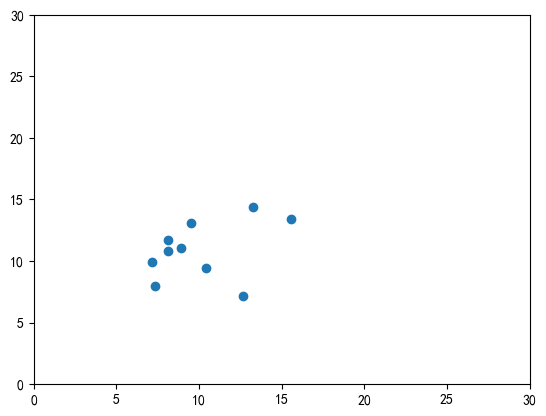

In [31]:
y_pred = model.predict(x_test_scaled)

plt.scatter(y_test,y_pred)
plt.xlim(0,30)
plt.ylim(0,30)

8.134561700609812 -0.6472840173760539
8.134561700609812 -0.12614028028488677


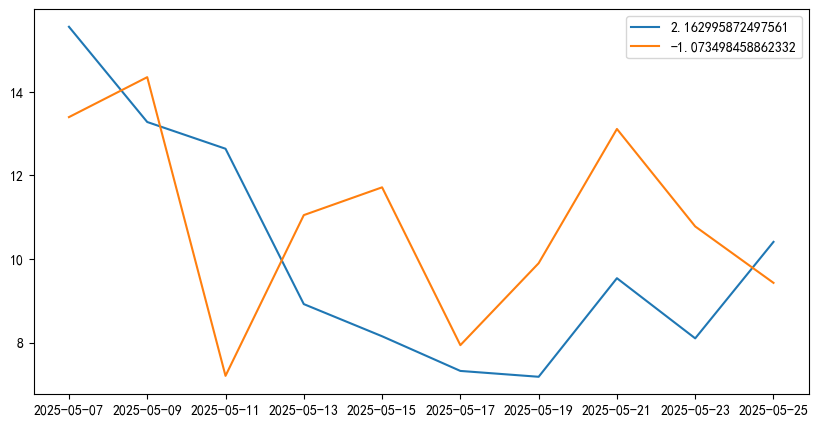

In [32]:
fig,axs = plt.subplots(figsize=(10,5))
axs.plot(x_test.index,y_test,label='true')
axs.plot(x_test.index,y_pred,label='pred')
axs.legend((y_test-y_pred))
print(mean_squared_error(y_pred, y_test),r2_score(y_pred, y_test))
print(mean_squared_error(y_test, y_pred),r2_score(y_test, y_pred))#correct

Text(0.5, 1.0, 'feature importance analysis')

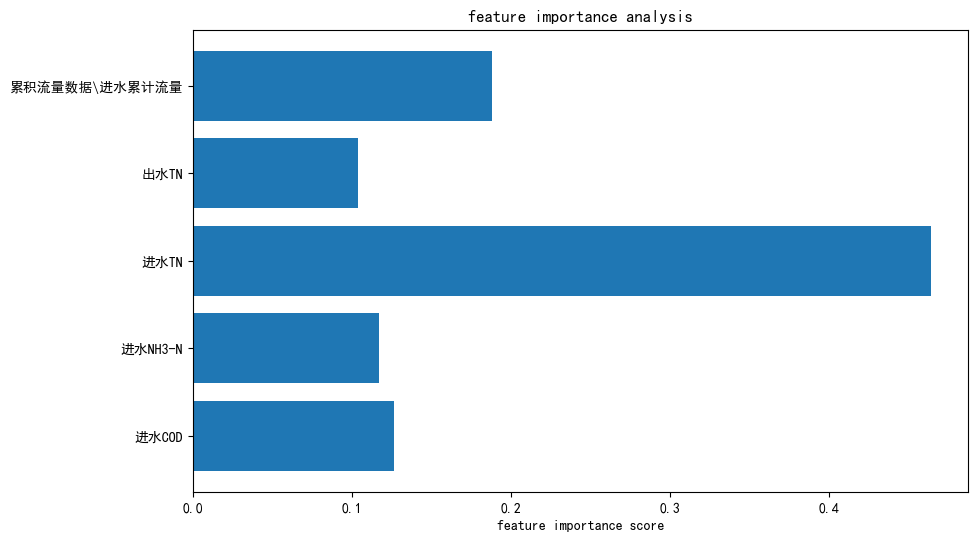

In [33]:
# 特征重要性分析
importance = model.feature_importances_
feature_name = x.columns

# 可视化
plt.figure(figsize=(10,6))
plt.barh(feature_name,importance)
plt.xlabel('feature importance score')
plt.title('feature importance analysis')

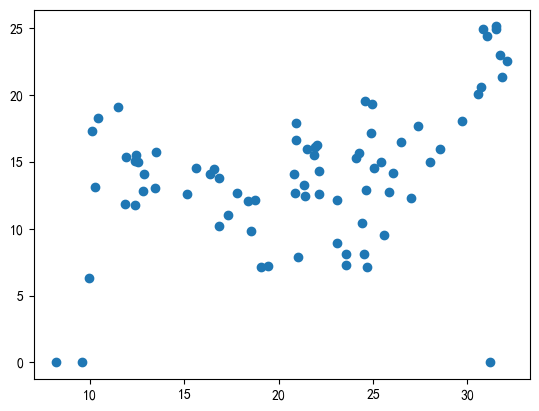

In [34]:
plt.scatter(x=df41['水温'],y=df21['加药累计流量\\北池碳源'])

## 应用

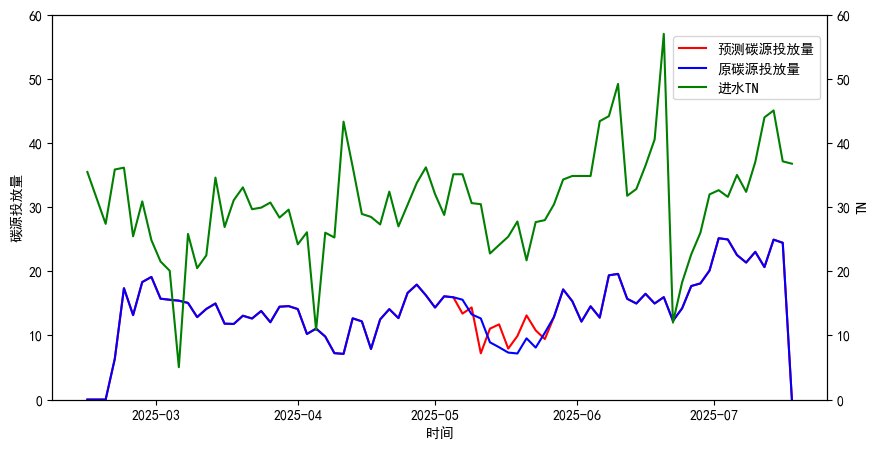

In [35]:
y_pred1 = model.predict(scaler.transform(x))

fig,ax1 = plt.subplots(figsize=(10,5))
ax1.plot(x.index,y_pred1,label='预测碳源投放量',c='red')
ax1.plot(x.index,y,label='原碳源投放量',c='blue')
ax1.set_ylabel('碳源投放量')
ax1.set_xlabel('时间')
ax1.set_ylim(0,60)

ax2 = ax1.twinx()
# axs.plot(x['进水COD'],label='进水COD')
ax2.plot(x['进水TN'],label='进水TN',c='green')
# axs.plot(x['出水TN'],label='出水TN')
ax2.set_ylabel('TN')
ax2.set_ylim(0,60)

fig.legend(bbox_to_anchor=(0.9, 0.85))
fig.savefig('xgboost_验证.jpg')

In [36]:
x0 = x.copy()
# x0['出水COD'] = 0
x0['出水TN'] = 7
# x0['出水NH3-N'] = 0
x0

,进水COD,进水NH3-N,进水TN,出水TN,累积流量数据\进水累计流量
2025-02-14,93.507,27.936,35.466,7,56779.25
2025-02-18,98.946,22.212,27.384,7,52645.75
2025-02-20,126.346,30.361,35.850,7,57458.00
2025-02-22,116.074,31.396,36.140,7,60155.75
2025-02-24,103.051,21.555,25.434,7,60443.50
...,...,...,...,...,...
2025-07-10,83.186,31.419,37.029,7,48093.50
2025-07-12,99.353,35.740,43.970,7,43929.50
2025-07-14,109.967,33.223,45.056,7,51099.50
2025-07-16,84.532,33.262,37.121,7,52238.00


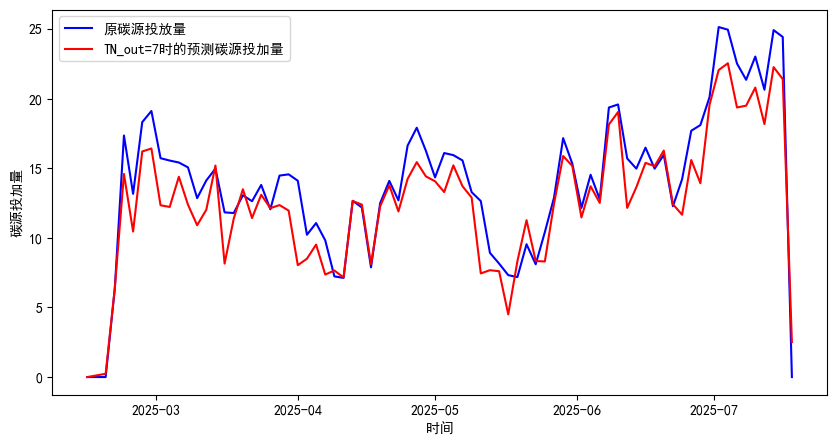

In [37]:
y_pred0 = model.predict(scaler.transform(x0))

fig,axs = plt.subplots(figsize=(10,5))
axs.plot(x.index,y,label='原碳源投放量',c='blue')
axs.plot(x.index,y_pred0,label='TN_out=7时的预测碳源投加量',c='red')
# axs.plot(x['进水COD'],label='进水COD')
# axs.plot(x['进水TN'],label='进水TN')
axs.legend()
axs.set_ylabel('碳源投加量')
axs.set_xlabel('时间')
fig.savefig('xgboost_应用.jpg')

In [38]:
# 碳源减少量
(y.values - y_pred0).sum() / y.sum()

0.09862767566090076

In [41]:
y_pred0.sum()

976.2944

In [40]:
y.sum()

1083.12

# LSTM

## 数据集

In [120]:
x

,进水COD,进水TP,进水NH3-N,进水TN,出水COD,出水TP,出水NH3-N,出水TN,累积流量数据\进水累计流量,水温,碳氮比
2025-02-14,93.507,3.156,27.936,35.466,-17.208,-0.227,-1.491,-3.058,56779.25,8.214048,2.636525
2025-02-18,98.946,1.693,22.212,27.384,-16.756,-0.261,-1.489,-3.562,52645.75,9.582292,3.613278
2025-02-20,126.346,2.340,30.361,35.850,-14.754,-0.251,-1.476,-4.745,57458.00,9.931111,3.524296
2025-02-22,116.074,2.347,31.396,36.140,-14.490,-0.249,-1.494,-2.705,60155.75,10.121667,3.211787
2025-02-24,103.051,1.669,21.555,25.434,-13.909,-0.264,-1.480,-5.290,60443.50,10.265625,4.051702
...,...,...,...,...,...,...,...,...,...,...,...
2025-07-10,83.186,3.079,31.419,37.029,-22.433,-0.214,-1.486,-4.379,48093.50,31.738571,2.246509
2025-07-12,99.353,3.558,35.740,43.970,-22.091,-0.226,-1.482,-5.932,43929.50,30.708837,2.259563
2025-07-14,109.967,3.885,33.223,45.056,-22.536,-0.247,-1.498,-5.263,51099.50,30.798444,2.440674
2025-07-16,84.532,2.785,33.262,37.121,-22.730,-0.223,-1.488,-4.353,52238.00,31.041628,2.277202


In [121]:
y

日期时间
2025-02-14     0.00
2025-02-18     0.00
2025-02-20     6.35
2025-02-22    17.35
2025-02-24    13.16
              ...  
2025-07-10    23.02
2025-07-12    20.64
2025-07-14    24.92
2025-07-16    24.43
2025-07-18     0.00
Name: 加药累计流量\北池碳源, Length: 77, dtype: float64

In [122]:
n = int(len(x) * 0.8)
x_train,x_test = x.iloc[0:n,:],x.iloc[n:,:]
y_train,y_test = y.iloc[0:n],y.iloc[n:]

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) # fit: 计算均值标准差，transform:利用统计量进行标准化
x_test_scaled = scaler.transform(x_test) # 不再计算均值标准差，仅在训练集上拟合

In [123]:
from torch.utils.data import Dataset,DataLoader
import torch

class waterTreatmentDataset(Dataset):
    def __init__(self,data,target,window_size=3):
        self.x,self.y = self.create_sequence(data,target,window_size)
    
    def create_sequence(self,data,target,window_siez):
        x_seq,y_seq = [],[]
        for i in range(len(data)-window_size):
            window = data[i:i+window_size]
            target_val = target[i+window_size]
            x_seq.append(window)
            y_seq.append(target_val)
        return torch.tensor(x_seq,dtype=torch.float32),torch.tensor(y_seq,dtype=torch.float32)
    
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self,idx):
        return self.x[idx],self.y[idx]

window_size = 3
train_dataset = waterTreatmentDataset(x_train_scaled,y_train)
test_dataset = waterTreatmentDataset(x_test_scaled,y_test)

batch_size = 32
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

## 模型训练

Epoch [10/50], Train Loss: 187.4848, Test Loss: 428.6111, LR: 0.001000
Epoch [20/50], Train Loss: 147.4618, Test Loss: 367.9225, LR: 0.001000
Epoch [30/50], Train Loss: 45.3688, Test Loss: 188.1421, LR: 0.001000
Epoch [40/50], Train Loss: 15.4537, Test Loss: 93.8702, LR: 0.001000
Epoch [50/50], Train Loss: 13.7699, Test Loss: 87.3780, LR: 0.001000


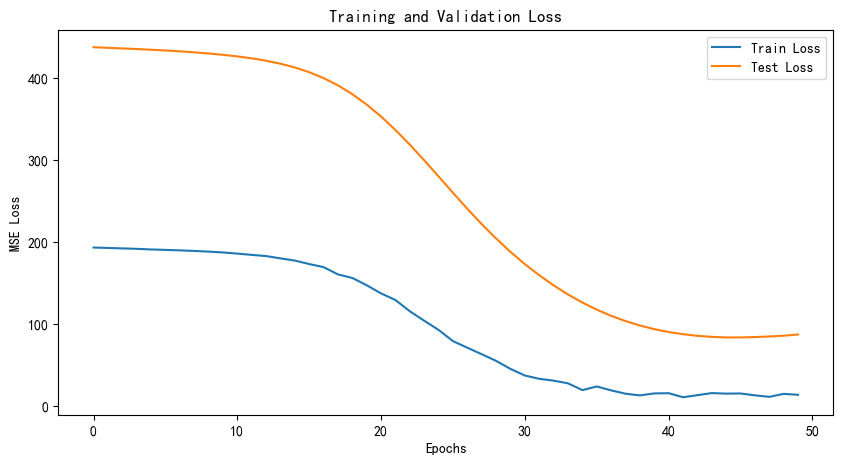

In [127]:
import torch.nn as nn
import torch.optim as optim

class carbonLSTMModel(nn.Module):
    def __init__(self,input_size,hidden_size=64,num_layers=2,output_size=1):
        super(carbonLSTMModel,self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # lstm层
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True, # 输入形状（batch,seq_len,features）
            dropout = 0.2
        )
        
        # 全连接层
        self.fc = nn.Sequential(
            nn.Linear(hidden_size,32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32,output_size)
        )
        
    def forward(self,x):
        # 初始化隐藏状态
        h0 = torch.zeros(self.num_layers,x.size(0),self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers,x.size(0),self.hidden_size).to(x.device)
        
        # lstm前向传播
        out,(hn,cn) = self.lstm(x,(h0,c0))
        
        # 只取最后一个时间步的输出
        out = out[:, -1, :]
        
        # 全连接层
        out = self.fc(out)
        
        return out
    
def train_model(model,train_loader,test_loader,epochs=100,lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(),lr=lr)
    # 在监测的指标（如验证损失）停止改善时自动降低学习率
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                     'min', # 监测指标的目标：最小化
                                                     patience=5, # 容忍多少个 epoch 没有改善
                                                     factor=0.5) # 学习率降低的因子（新学习率 = 旧学习率 * factor）
    
    train_losses,test_losses = [],[]
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        train_loss = 0
        for batch_x,batch_y in train_loader:
            batch_x,batch_y = batch_x.to(device),batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs.squeeze(),batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # 验证阶段
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for batch_x,batch_y in test_loader:
                batch_x,batch_y =  batch_x.to(device),batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs.squeeze(),batch_y)
                test_loss += loss.item()
        
        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)
        scheduler.step(avg_test_loss) # ReduceLROnPlateau 调度器会根据验证集指标（如损失）的变化自动降低学习率
        
        # 打印训练进度
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], '
                  f'Train Loss: {avg_train_loss:.4f}, '
                  f'Test Loss: {avg_test_loss:.4f}, '
                  f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
        
    # 绘制损失曲线
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.show()
    
    return model

# 模型初始化
input_size = x_train_scaled.shape[1] # 特征数量
model = carbonLSTMModel(input_size=input_size)

# 开始训练
trained_model = train_model(model,train_loader,test_loader,epochs=50)

## 模型评估

Test Metrics:
RMSE: 9.3476
MAE: 8.6485
MAPE: 36.60%
R²: -1.0493


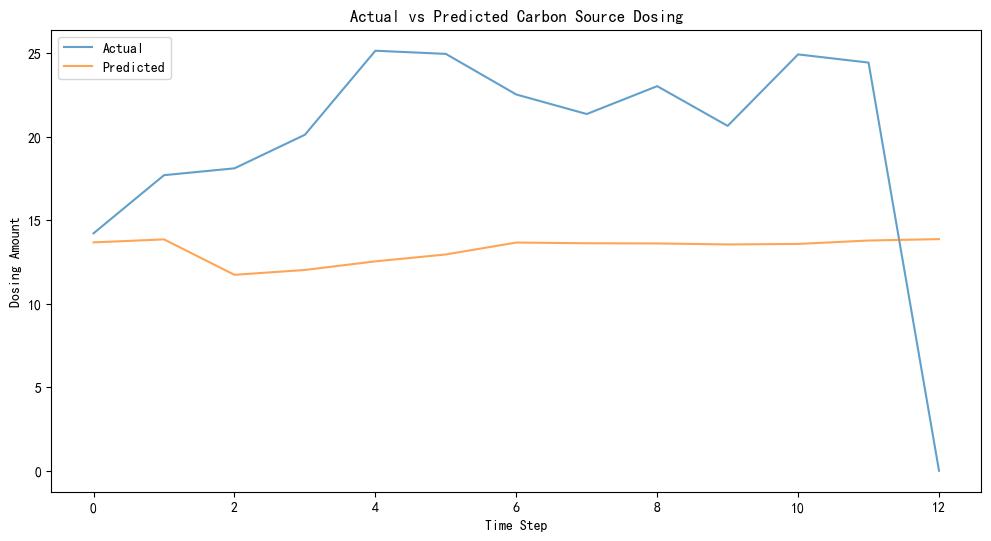

In [128]:
def evaluate_model(model,test_loader):
    device = next(model.parameters()).device
    model.eval()
    
    actuals,predictions = [],[]
    with torch.no_grad():
        for batch_x,batch_y in test_loader:
            batch_x =  batch_x.to(device)
            outputs = model(batch_x).squeeze().cpu().numpy()
            
            predictions.extend(outputs)
            actuals.extend(batch_y.numpy())
    
    # 计算指标
    actuals = np.array(actuals)
    predictions = np.array(predictions)
    
    # RMSE
    rmse = np.sqrt(np.mean((actuals - predictions) ** 2))
    # MAE
    mae = np.mean(np.abs(actuals - predictions))
    # MAPE (避免除零)
    mask = actuals != 0
    mape = np.mean(np.abs((actuals[mask] - predictions[mask]) / actuals[mask])) * 100
    # R²
    r2 = 1 - np.sum((actuals - predictions) ** 2) / np.sum((actuals - np.mean(actuals)) ** 2)
    
    print(f'Test Metrics:')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')
    print(f'MAPE: {mape:.2f}%')
    print(f'R²: {r2:.4f}')
    
    # 绘制实际 vs 预测
    plt.figure(figsize=(12, 6))
    plt.plot(actuals[:200], label='Actual', alpha=0.7)
    plt.plot(predictions[:200], label='Predicted', alpha=0.7)
    plt.title('Actual vs Predicted Carbon Source Dosing')
    plt.xlabel('Time Step')
    plt.ylabel('Dosing Amount')
    plt.legend()
    plt.show()
    
    return actuals, predictions

# 评估模型
actuals, predictions = evaluate_model(trained_model, test_loader)

Test Metrics:
RMSE: 4.7565
MAE: 3.4739
MAPE: 23.49%
R²: -0.0565


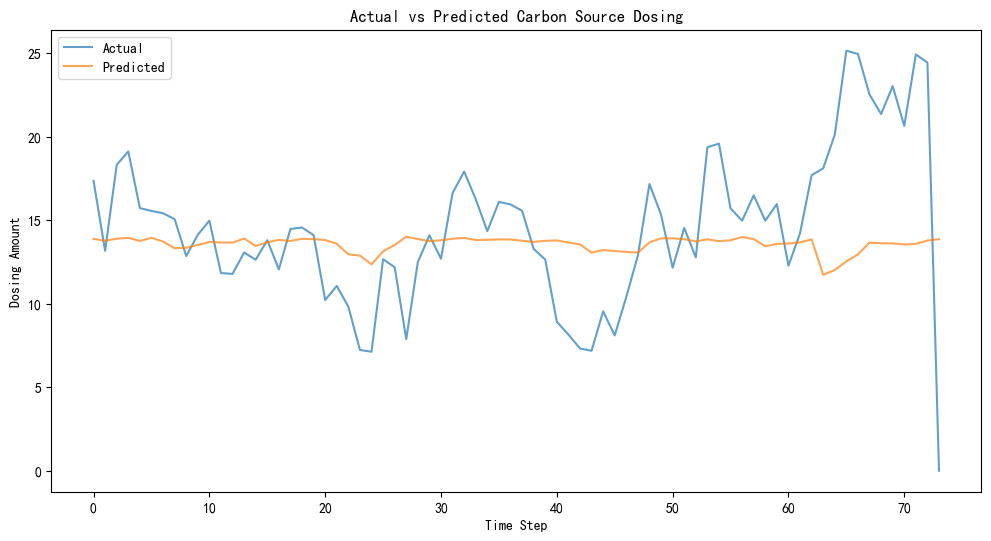

In [129]:
# 全数据预测
dataset = waterTreatmentDataset(scaler.transform(x),y)
batch_size = 32
data_loader = DataLoader(dataset,batch_size=batch_size,shuffle=False)

actuals, predictions = evaluate_model(trained_model, data_loader)

# 测试加药除磷

## 相关数据

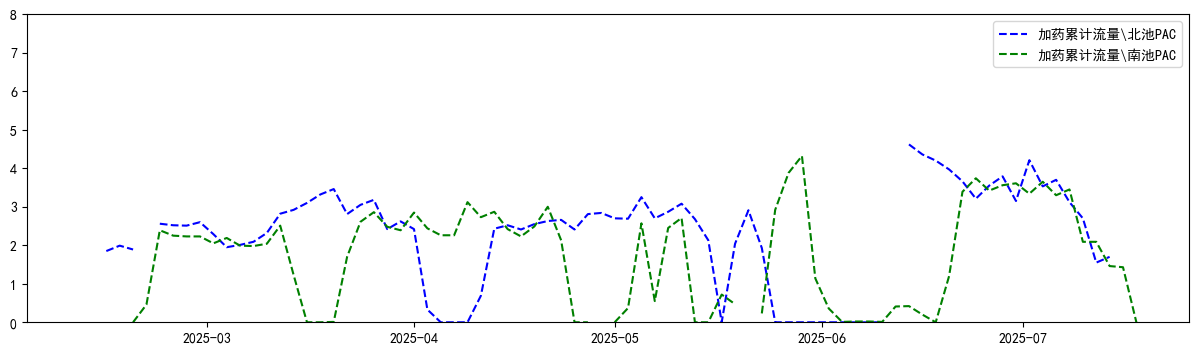

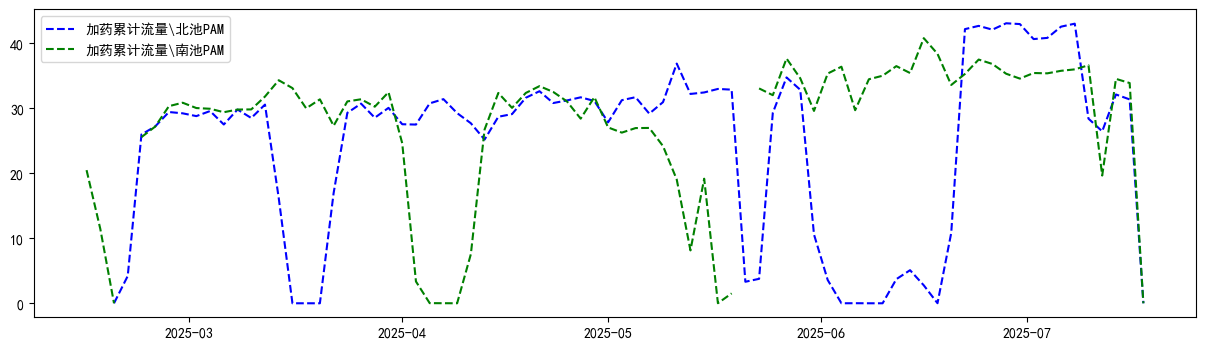

In [26]:
for c in ['PAC','PAM']:
    fig,ax = plt.subplots(figsize=(15,4))
    ax.plot(df21[f'加药累计流量\北池{c}'],c='b',ls='--',label=f'加药累计流量\北池{c}')
    ax.plot(df21[f'加药累计流量\南池{c}'],c='g',ls='--',label=f'加药累计流量\南池{c}')
    ax.legend()
    if c == 'PAC':
        ax.set_ylim([0,8])

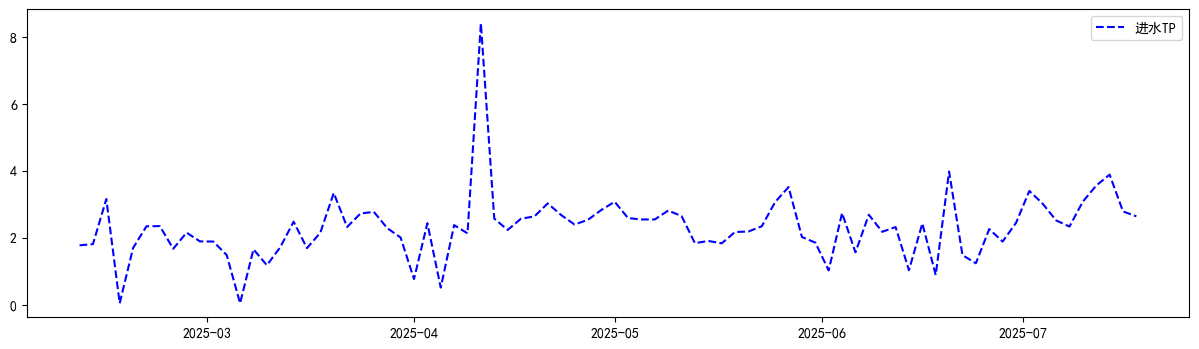

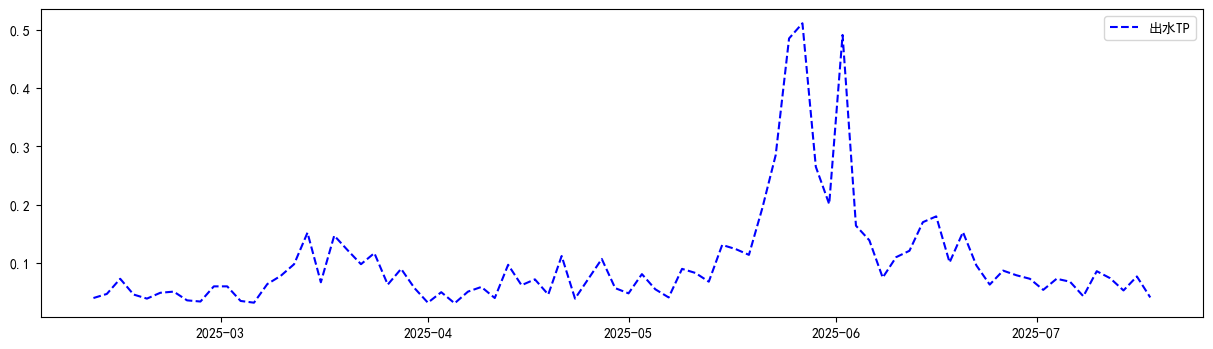

In [27]:
for c in ['进水TP','出水TP']:
    fig,ax = plt.subplots(figsize=(15,4))
    ax.plot(df11[c],c='b',ls='--',label=c)
    ax.legend()

## 加药与进出水总磷关系

Text(0, 0.5, '加药累计流量\\北池PAC')

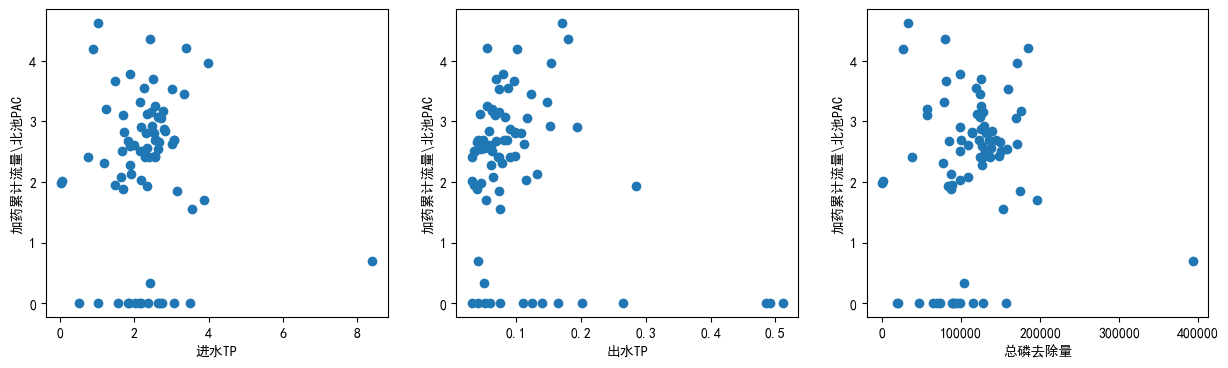

In [37]:
df21 = df21.mask(df21>1000)
fig,axs = plt.subplots(1,3,figsize=(15,4))
axs[0].scatter(x=df11['进水TP'],y=df21['加药累计流量\北池PAC'])
axs[0].set_xlabel('进水TP')
axs[0].set_ylabel('加药累计流量\北池PAC')
axs[1].scatter(x=df11['出水TP'],y=df21['加药累计流量\北池PAC'])
axs[1].set_xlabel('出水TP')
axs[1].set_ylabel('加药累计流量\北池PAC')
axs[2].scatter(x=(df11['进水TP']-df11['出水TP'])*df31['累积流量数据\进水累计流量'],y=df21['加药累计流量\北池PAC'])
axs[2].set_xlabel('总磷去除量')
axs[2].set_ylabel('加药累计流量\北池PAC')

Text(0, 0.5, '加药累计流量\\南池PAC')

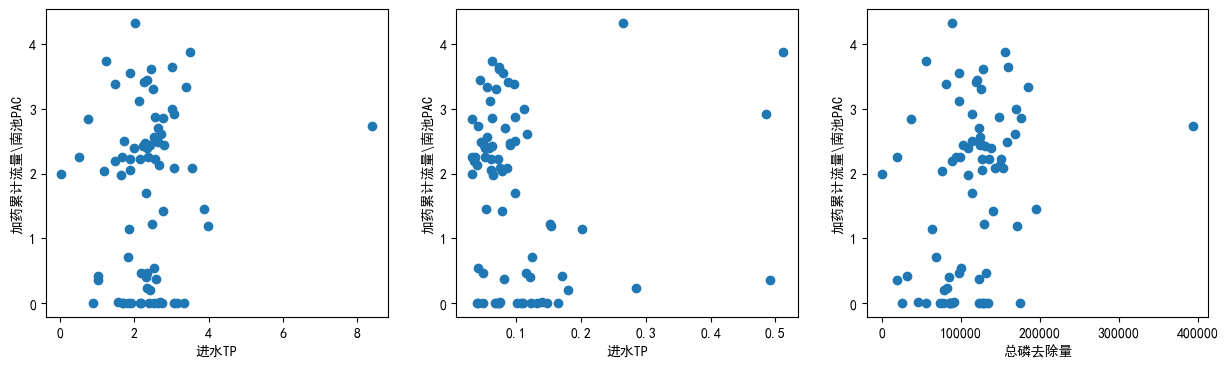

In [38]:
fig,axs = plt.subplots(1,3,figsize=(15,4))
axs[0].scatter(x=df11['进水TP'],y=df21['加药累计流量\南池PAC'])
axs[0].set_xlabel('进水TP')
axs[0].set_ylabel('加药累计流量\南池PAC')
axs[1].scatter(x=df11['出水TP'],y=df21['加药累计流量\南池PAC'])
axs[1].set_xlabel('进水TP')
axs[1].set_ylabel('加药累计流量\南池PAC')
axs[2].scatter(x=(df11['进水TP']-df11['出水TP'])*df31['累积流量数据\进水累计流量'],y=df21['加药累计流量\南池PAC'])
axs[2].set_xlabel('总磷去除量')
axs[2].set_ylabel('加药累计流量\南池PAC')


Text(0, 0.5, '加药累计流量\\南北池PAC')

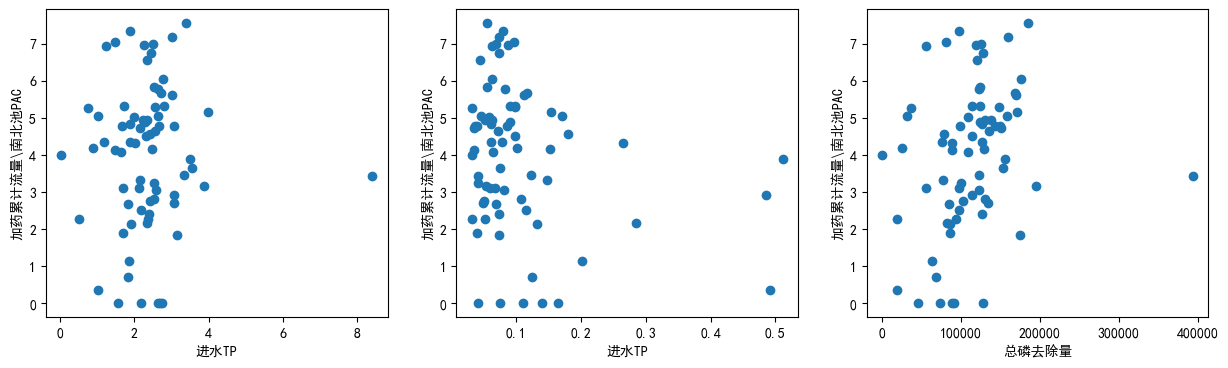

In [39]:
fig,axs = plt.subplots(1,3,figsize=(15,4))
axs[0].scatter(x=df11['进水TP'],y=df21['加药累计流量\南池PAC']+df21['加药累计流量\北池PAC'])
axs[0].set_xlabel('进水TP')
axs[0].set_ylabel('加药累计流量\南北池PAC')
axs[1].scatter(x=df11['出水TP'],y=df21['加药累计流量\南池PAC']+df21['加药累计流量\北池PAC'])
axs[1].set_xlabel('进水TP')
axs[1].set_ylabel('加药累计流量\南北池PAC')
axs[2].scatter(x=(df11['进水TP']-df11['出水TP'])*df31['累积流量数据\进水累计流量'],y=df21['加药累计流量\南池PAC']+df21['加药累计流量\北池PAC'])
axs[2].set_xlabel('总磷去除量')
axs[2].set_ylabel('加药累计流量\南北池PAC')

## XGBoost

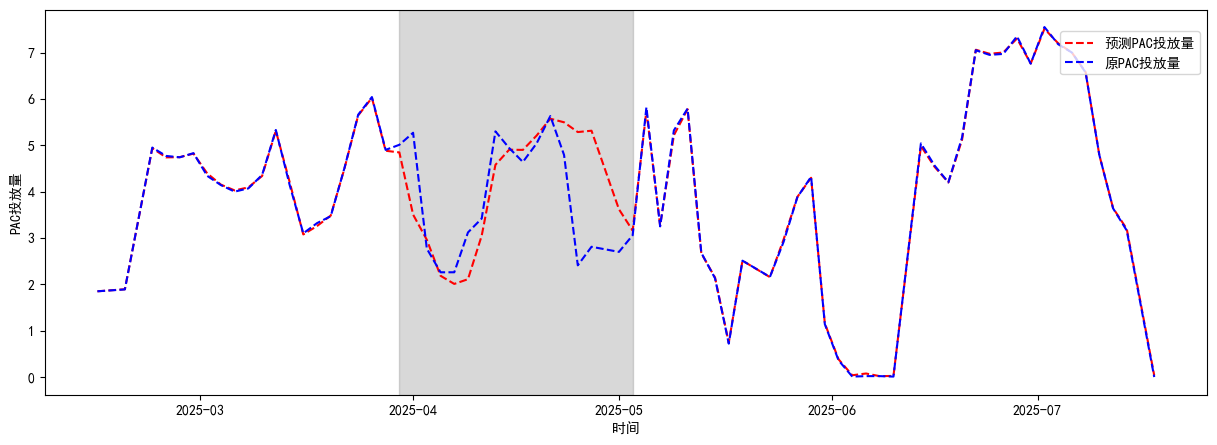

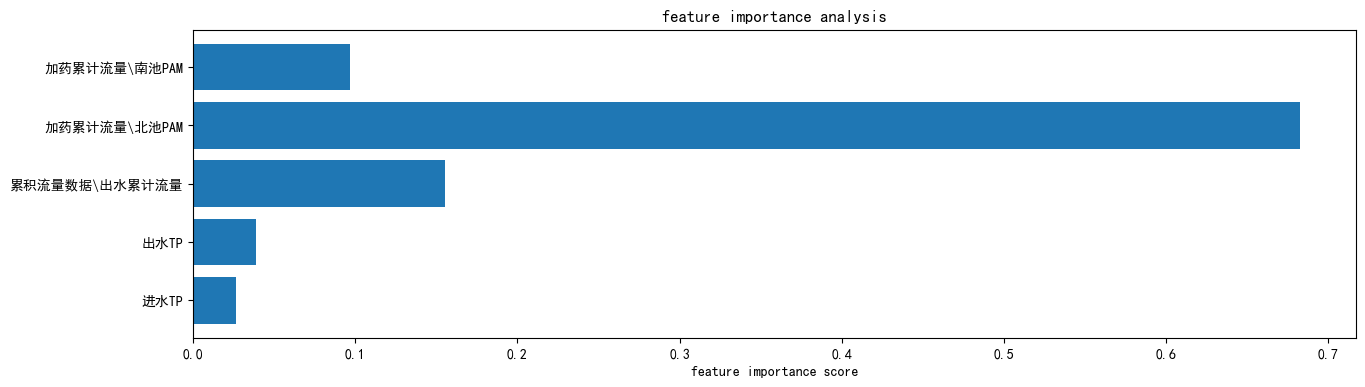

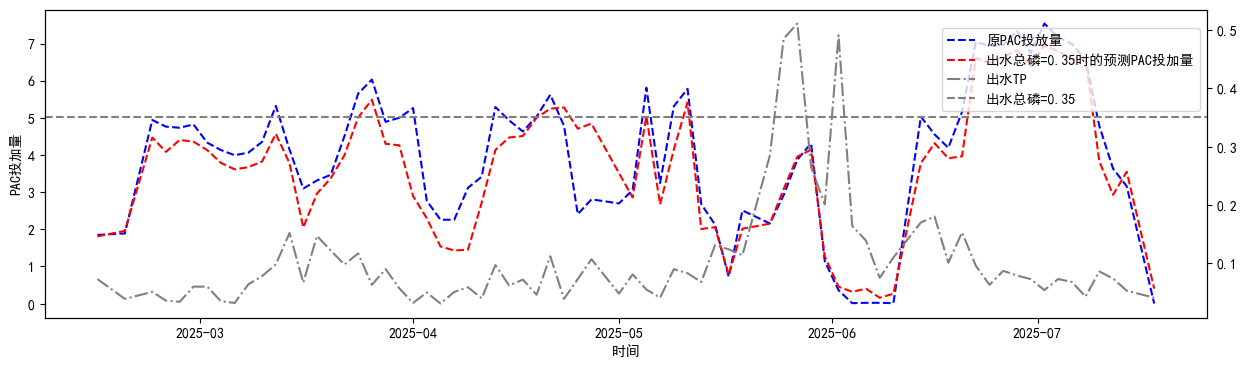

In [69]:
x = pd.concat([
    df11[['进水TP','出水TP']],
    df31['累积流量数据\出水累计流量'],
    df21[['加药累计流量\北池PAM','加药累计流量\南池PAM']]
],axis=1)    
y = df21['加药累计流量\北池PAC']+df21['加药累计流量\南池PAC']

## 剔除 聚铁为0的数据
x = x[~y.isnull()]
y = y[~y.isnull()]

# split dataset
idx1,idx2 = 20,36 # 区间内为测试数据，区间外训练数据
train_idx = list(range(0,idx1))
train_idx.extend(list(range(idx2,len(x))))
x_train,x_test = x.iloc[train_idx,:],x.iloc[idx1:idx2,:]
y_train,y_test = y.iloc[train_idx],y.iloc[idx1:idx2]

# normalize
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) # fit: 计算均值标准差，transform:利用统计量进行标准化
x_test_scaled = scaler.transform(x_test) # 不再计算均值标准差，仅在训练集上拟合

# training
model = XGBRegressor(
    n_estimators = 100, # 树的数量（迭代次数）
    max_depth = 5, # 每棵树的最大深度
    learning_rate=0.1, # 学习率
    subsample=0.8, # 训练每棵树时使用的样本比例
    random_state=42 # 随机种子，确保结果可复现
)

model.fit(x_train_scaled,y_train)

# predict
y_pred1 = model.predict(scaler.transform(x))

# show reuslt
fig,ax1 = plt.subplots(figsize=(15,5))

ax1.plot(x.index,y_pred1,label='预测PAC投放量',c='red',ls='--')
ax1.plot(x.index,y,label='原PAC投放量',c='blue',ls='--')
ax1.set_ylabel('PAC投放量')
ax1.set_xlabel('时间')
ax1.axvspan(x.index[idx1], x.index[idx2], alpha=0.3,color='gray')

fig.legend(bbox_to_anchor=(0.9, 0.85))

# 特征重要性分析
importance = model.feature_importances_
feature_name = x.columns

# 可视化
plt.figure(figsize=(15,4))
plt.barh(feature_name,importance)
plt.xlabel('feature importance score')
plt.title('feature importance analysis')

# 约束输出总磷条件下预估聚铁投加量
x0 = x.copy()
thred = 0.5*0.7
x0['出水TP'] = thred
y_pred0 = model.predict(scaler.transform(x0))

fig,axs = plt.subplots(figsize=(15,4))
axs.plot(x.index,y,label='原PAC投放量',c='blue',ls='--')
axs.plot(x.index,y_pred0,label=f'出水总磷={thred}时的预测PAC投加量',c='red',ls='--')
axs.set_ylabel('PAC投加量')
axs.set_xlabel('时间')

ax2 = axs.twinx()
ax2.plot(x['出水TP'],label='出水TP',ls='-.',c='gray')
ax2.axhline(thred,label=f'出水总磷={thred}',c='gray',ls='--')
fig.legend(bbox_to_anchor=(0.9,0.85))

In [47]:
x

,进水TP,出水TP,累积流量数据\出水累计流量
日期时间,,,
2025-02-10,1.772,0.040,35230.50
2025-02-12,1.808,0.047,42164.75
2025-02-14,3.156,0.073,52633.00
2025-02-16,0.040,0.046,48019.00
2025-02-18,1.693,0.039,49956.00
...,...,...,...
2025-07-10,3.079,0.086,39198.00
2025-07-12,3.558,0.074,39590.50
2025-07-14,3.885,0.053,48327.50


In [49]:
y.isnull()

日期时间
2025-02-10     True
2025-02-12     True
2025-02-14    False
2025-02-16     True
2025-02-18    False
              ...  
2025-07-10    False
2025-07-12    False
2025-07-14    False
2025-07-16     True
2025-07-18    False
Freq: 2D, Length: 80, dtype: bool

In [67]:
len(y)

72